In [40]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [41]:
OPTIONS = json.loads(open('../../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'static_tests': {'target': 1, 'reference': 1},
 'dynamic_tests': {'target': 1, 'reference': 1}}

In [42]:
TEST_NUM = OPTIONS['dynamic_tests'].get('reference')
PATH     = f'files/test{TEST_NUM}'
print(PATH)

INFO = json.loads(open(f'{PATH}/info.json', 'r', encoding='utf-8').read())
INFO

files/test1


{'variable': 'roll', 'limits': [0, 1000000000.0]}

In [43]:
TARGET_VAR  = INFO.get('variable')
TEST_VAR    = OPTIONS.get('test')
TARGET_TIME = tuple(INFO.get('limits'))

# IMPORTANDO DADOS

In [44]:
df = pd.read_csv(f'{PATH}/data.csv')
df.loc[:, 'time'] = df.time - df.time.values[0]
df

,ay,q0,wy,roll,wx,la_pos_mon_d,time,yaw,q2,az,ax,q3,q1,pitch,sample_time,wz
0,-9.787,1.0000,0.000027,0.000034,0.000306,0.0,0.000000,-0.000709,-0.000031,0.15230,0.01111,-0.000355,0.000018,-0.000061,605000000.0,-0.000076
1,-9.789,1.0000,-0.000010,0.000031,0.000062,0.0,0.101275,-0.000713,-0.000038,0.15230,0.01068,-0.000358,0.000016,-0.000072,705000000.0,-0.000050
2,-9.788,1.0000,-0.000206,0.000038,0.000134,0.0,0.201469,-0.000721,-0.000047,0.15220,0.01081,-0.000362,0.000020,-0.000092,805000000.0,0.000065
3,-9.788,1.0000,-0.000059,0.000034,-0.000154,0.0,0.309372,-0.000744,-0.000045,0.15230,0.01100,-0.000372,0.000018,-0.000088,905000000.0,-0.000058
4,-9.788,1.0000,-0.000095,0.000031,-0.000150,0.0,0.404137,-0.000755,-0.000053,0.15230,0.01050,-0.000378,0.000016,-0.000103,5000000.0,-0.000138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3021,-9.788,0.4250,-0.036780,1.594000,-0.009329,10.0,302.109516,1.560000,0.431700,-0.08825,-0.04890,0.555200,0.569800,-0.269000,705000000.0,0.000421
3022,-9.787,0.4260,-0.036960,1.594000,-0.009685,10.0,302.205482,1.556000,0.430700,-0.08842,-0.04899,0.554400,0.570600,-0.269000,805000000.0,0.000725
3023,-9.788,0.4271,-0.036710,1.594000,-0.009451,10.0,302.312336,1.552000,0.429600,-0.08850,-0.04888,0.553600,0.571500,-0.268900,905000000.0,0.000416
3024,-9.787,0.4282,-0.036920,1.594000,-0.009683,10.0,302.408922,1.548000,0.428600,-0.08829,-0.04897,0.552700,0.572300,-0.268900,5000000.0,0.000378


- Convertendo pra radianos

In [45]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,ay,q0,wy,roll,wx,la_pos_mon_d,time,yaw,q2,az,ax,q3,q1,pitch,sample_time,wz
0,-9.787,1.0000,0.001553,0.001966,0.017538,0.0,0.000000,-0.040646,-0.000031,0.15230,0.01111,-0.000355,0.000018,-0.003496,605000000.0,-0.004376
1,-9.789,1.0000,-0.000566,0.001748,0.003532,0.0,0.101275,-0.040863,-0.000038,0.15230,0.01068,-0.000358,0.000016,-0.004152,705000000.0,-0.002839
2,-9.788,1.0000,-0.011780,0.002185,0.007701,0.0,0.201469,-0.041299,-0.000047,0.15220,0.01081,-0.000362,0.000020,-0.005244,805000000.0,0.003741
3,-9.788,1.0000,-0.003378,0.001966,-0.008852,0.0,0.309372,-0.042611,-0.000045,0.15230,0.01100,-0.000372,0.000018,-0.005026,905000000.0,-0.003298
4,-9.788,1.0000,-0.005427,0.001748,-0.008612,0.0,0.404137,-0.043264,-0.000053,0.15230,0.01050,-0.000378,0.000016,-0.005901,5000000.0,-0.007884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3021,-9.788,0.4250,-2.107339,91.329473,-0.534512,10.0,302.109516,89.381416,0.431700,-0.08825,-0.04890,0.555200,0.569800,-15.412565,705000000.0,0.024150
3022,-9.787,0.4260,-2.117652,91.329473,-0.554910,10.0,302.205482,89.152233,0.430700,-0.08842,-0.04899,0.554400,0.570600,-15.412565,805000000.0,0.041522
3023,-9.788,0.4271,-2.103328,91.329473,-0.541502,10.0,302.312336,88.923050,0.429600,-0.08850,-0.04888,0.553600,0.571500,-15.406835,905000000.0,0.023864
3024,-9.787,0.4282,-2.115360,91.329473,-0.554795,10.0,302.408922,88.693867,0.428600,-0.08829,-0.04897,0.552700,0.572300,-15.406835,5000000.0,0.021675


# VISUALIZAÇÃO DE VARIÁVEIS

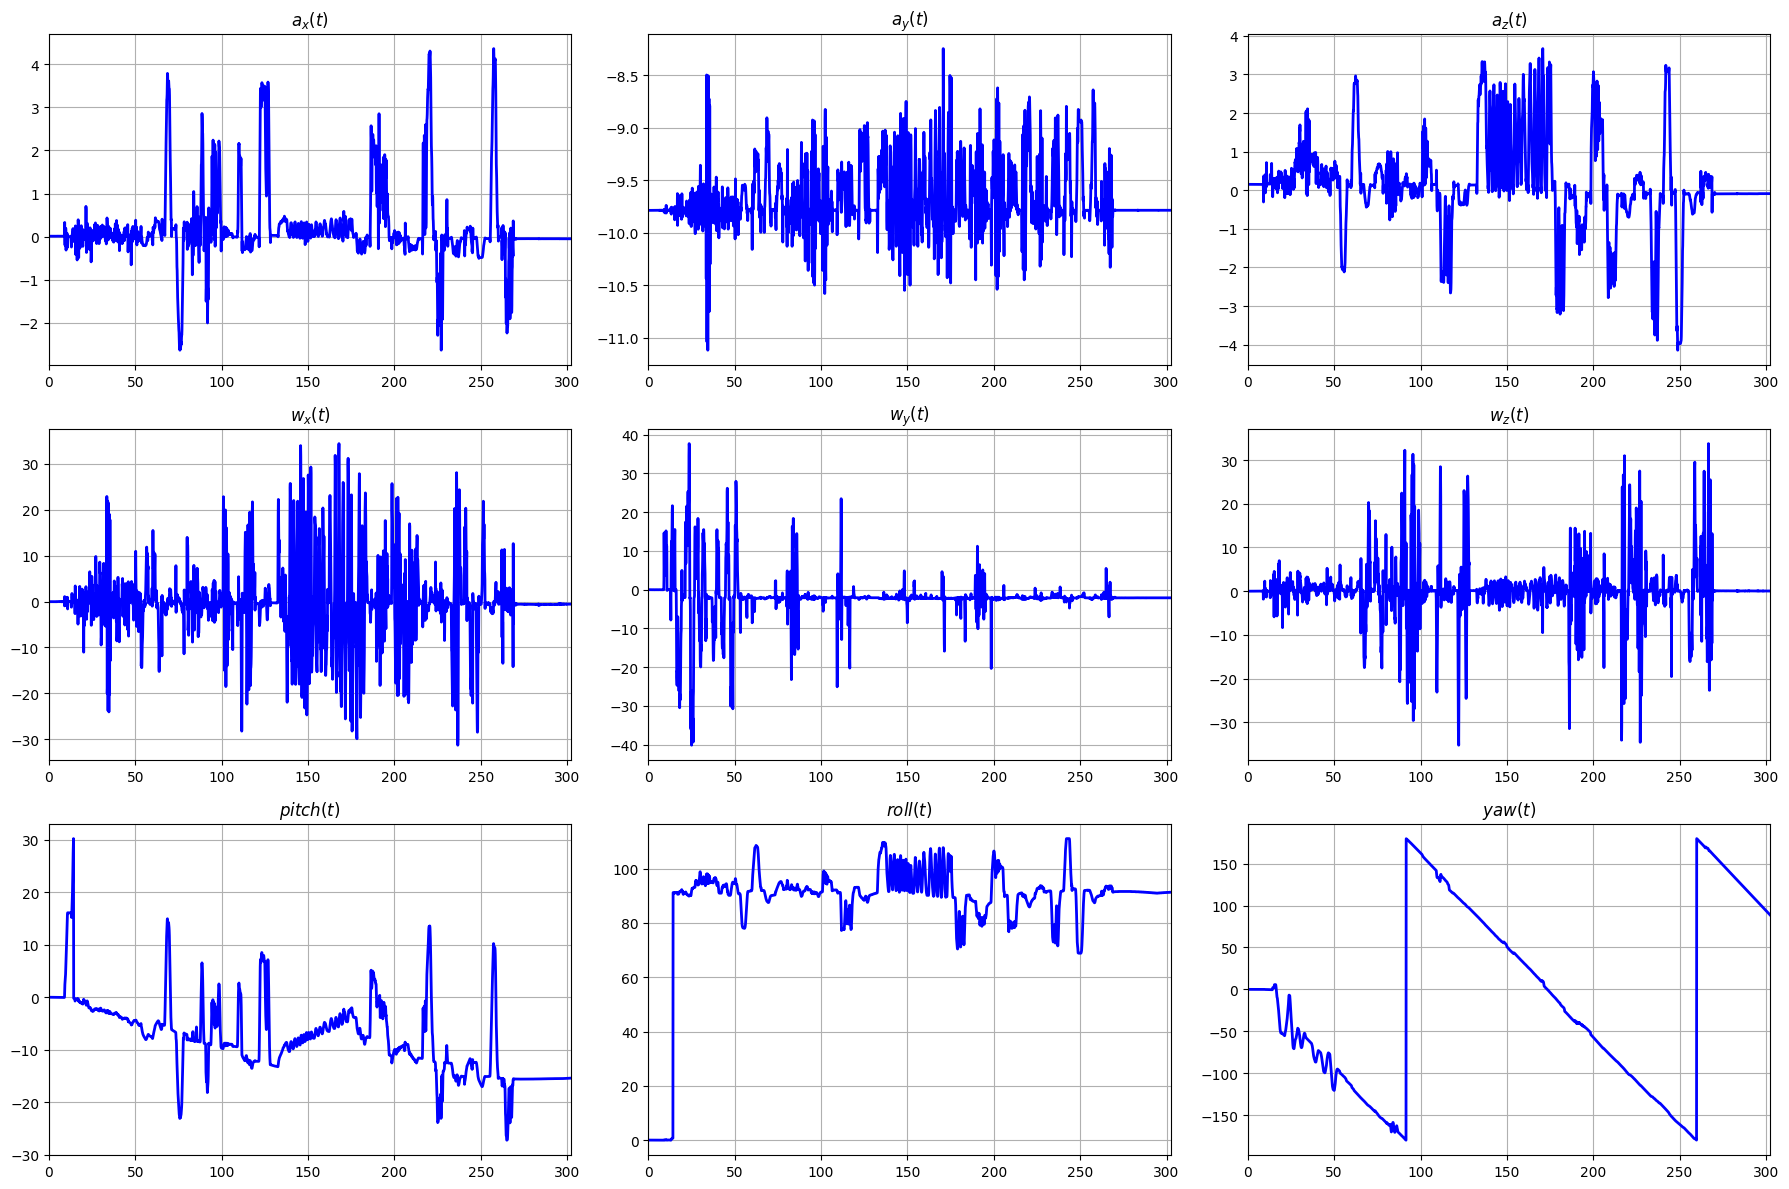

In [46]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals, color='blue', linewidth=2)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

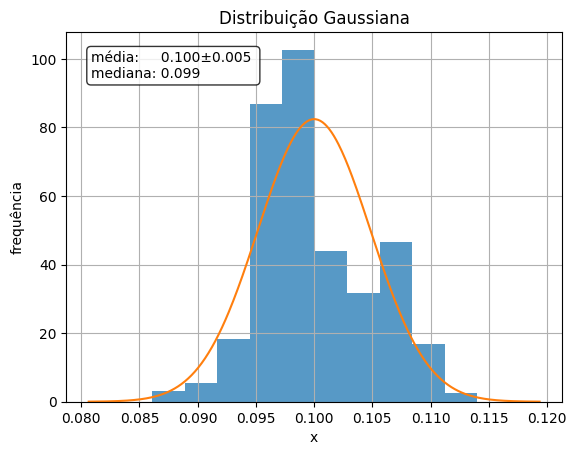

In [47]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time)

In [48]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,ay,q0,wy,roll,wx,la_pos_mon_d,yaw,q2,az,ax,q3,q1,pitch,sample_time,wz
0,0.0,-9.787,1.0000,0.001553,0.001966,0.017538,0.0,-0.040646,-0.000031,0.15230,0.01111,-0.000355,0.000018,-0.003496,605000000.0,-0.004376
1,0.1,-9.787,1.0000,0.001553,0.001966,0.017538,0.0,-0.040646,-0.000031,0.15230,0.01111,-0.000355,0.000018,-0.003496,605000000.0,-0.004376
2,0.2,-9.789,1.0000,-0.000566,0.001748,0.003532,0.0,-0.040863,-0.000038,0.15230,0.01068,-0.000358,0.000016,-0.004152,705000000.0,-0.002839
3,0.3,-9.788,1.0000,-0.011780,0.002185,0.007701,0.0,-0.041299,-0.000047,0.15220,0.01081,-0.000362,0.000020,-0.005244,805000000.0,0.003741
4,0.4,-9.788,1.0000,-0.003378,0.001966,-0.008852,0.0,-0.042611,-0.000045,0.15230,0.01100,-0.000372,0.000018,-0.005026,905000000.0,-0.003298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3022,302.2,-9.788,0.4250,-2.107339,91.329473,-0.534512,10.0,89.381416,0.431700,-0.08825,-0.04890,0.555200,0.569800,-15.412565,705000000.0,0.024150
3023,302.3,-9.787,0.4260,-2.117652,91.329473,-0.554910,10.0,89.152233,0.430700,-0.08842,-0.04899,0.554400,0.570600,-15.412565,805000000.0,0.041522
3024,302.4,-9.788,0.4271,-2.103328,91.329473,-0.541502,10.0,88.923050,0.429600,-0.08850,-0.04888,0.553600,0.571500,-15.406835,905000000.0,0.023864
3025,302.5,-9.787,0.4282,-2.115360,91.329473,-0.554795,10.0,88.693867,0.428600,-0.08829,-0.04897,0.552700,0.572300,-15.406835,5000000.0,0.021675


# FILTRANDO POR VARIAVEL

In [49]:
df = df.loc[(df.time >= TARGET_TIME[0]) & (df.time <= TARGET_TIME[1])]
df.loc[:, 'time'] = df.time - df.time.values[0]

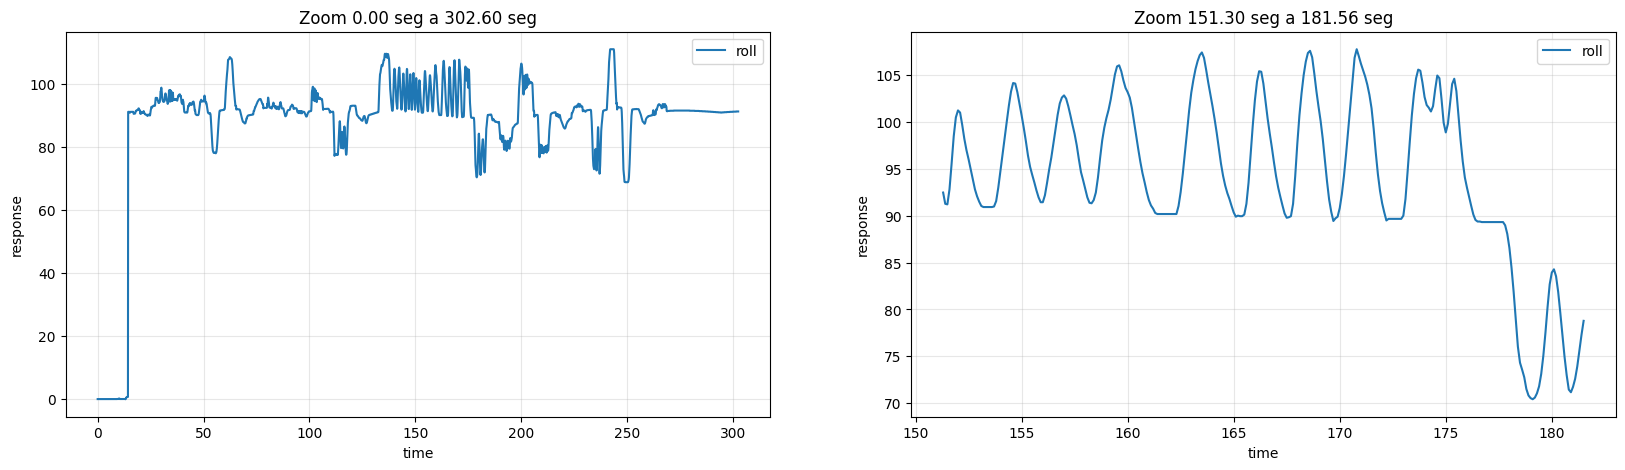

In [50]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [51]:
df = df.rename(columns={col: 'ref_' + col for col in df.columns if col != 'time'})
df

,time,ref_ay,ref_q0,ref_wy,ref_roll,ref_wx,ref_la_pos_mon_d,ref_yaw,ref_q2,ref_az,ref_ax,ref_q3,ref_q1,ref_pitch,ref_sample_time,ref_wz
0,0.0,-9.787,1.0000,0.001553,0.001966,0.017538,0.0,-0.040646,-0.000031,0.15230,0.01111,-0.000355,0.000018,-0.003496,605000000.0,-0.004376
1,0.1,-9.787,1.0000,0.001553,0.001966,0.017538,0.0,-0.040646,-0.000031,0.15230,0.01111,-0.000355,0.000018,-0.003496,605000000.0,-0.004376
2,0.2,-9.789,1.0000,-0.000566,0.001748,0.003532,0.0,-0.040863,-0.000038,0.15230,0.01068,-0.000358,0.000016,-0.004152,705000000.0,-0.002839
3,0.3,-9.788,1.0000,-0.011780,0.002185,0.007701,0.0,-0.041299,-0.000047,0.15220,0.01081,-0.000362,0.000020,-0.005244,805000000.0,0.003741
4,0.4,-9.788,1.0000,-0.003378,0.001966,-0.008852,0.0,-0.042611,-0.000045,0.15230,0.01100,-0.000372,0.000018,-0.005026,905000000.0,-0.003298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3022,302.2,-9.788,0.4250,-2.107339,91.329473,-0.534512,10.0,89.381416,0.431700,-0.08825,-0.04890,0.555200,0.569800,-15.412565,705000000.0,0.024150
3023,302.3,-9.787,0.4260,-2.117652,91.329473,-0.554910,10.0,89.152233,0.430700,-0.08842,-0.04899,0.554400,0.570600,-15.412565,805000000.0,0.041522
3024,302.4,-9.788,0.4271,-2.103328,91.329473,-0.541502,10.0,88.923050,0.429600,-0.08850,-0.04888,0.553600,0.571500,-15.406835,905000000.0,0.023864
3025,302.5,-9.787,0.4282,-2.115360,91.329473,-0.554795,10.0,88.693867,0.428600,-0.08829,-0.04897,0.552700,0.572300,-15.406835,5000000.0,0.021675


In [52]:
os.makedirs(f'output', exist_ok=True)
INFO = {}

with open('output/info.json', 'w') as file:
    file.write(json.dumps(INFO, indent=4))

df.to_csv('output/data.csv', index=None)